In [1]:
from urllib.request import urlopen
from PIL import Image

puppy_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/puppy.png"
image = Image.open(urlopen(puppy_path)).convert("RGB")

caption = "a puppy playing in the snow"

In [3]:
from transformers import CLIPTokenizer, CLIPProcessor, CLIPModel

model_id = "openai/clip-vit-base-patch32"

clip_tokenizer = CLIPTokenizer.from_pretrained(model_id)
clip_processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id)

D:\python projects\hands_on_lmm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 30569.95it/s]


In [4]:
inputs = clip_tokenizer(caption, return_tensors="pt")
inputs
clip_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
text_embedding = model.get_text_features(**inputs)

In [5]:
processed_image = clip_processor(
    text=None,
    images=image,
    return_tensors="pt"
)["pixel_values"]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..2.145897].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

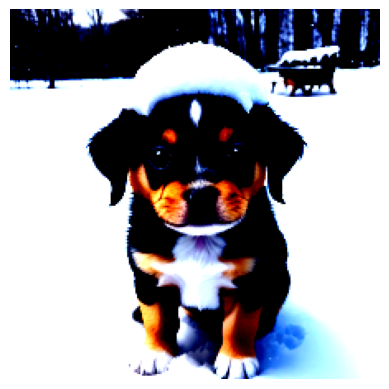

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

img = processed_image.squeeze(0)
img = img.permute(*torch.arange(img.ndim -1, -1, -1))
img = np.einsum("ijk->jik", img)

plt.imshow(img)
plt.axis("off")

In [21]:
vision_outputs = model.vision_model(pixel_values=processed_image)
image_embedding = model.visual_projection(vision_outputs.pooler_output)

text_outputs = model.text_model(**inputs)
text_embedding = model.text_projection(text_outputs.pooler_output)

text_embedding_norm = text_embedding / text_embedding.norm(dim=-1, keepdim=True)
image_embedding_norm = image_embedding / image_embedding.norm(dim=-1, keepdim=True)

text_np = text_embedding_norm.detach().cpu().numpy()
image_np = image_embedding_norm.detach().cpu().numpy()

score = np.dot(text_np, image_np.T)
score


array([[0.33149636]], dtype=float32)

In [ ]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration

blip_processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b", torch_dtype= torch.float16)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
car_path = "https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/chapter09/images/car.png"
image = Image.open(urlopen(car_path)).convert("RGB")

image

In [ ]:
inputs = blip_processor(image, return_tensors="pt").to(device, torch.float16)
inputs["pixel_values"].shape

In [ ]:
text = "Her vocalization was remarkably melodic"
token_ids = blip_processor(image, text=text, return_tensors="pt")
token_ids = token_ids.to(device, torch.float16)["input_ids"][0]

tokens = blip_processor.tokenizer.convert_ids_to_tokens(token_ids)
tokens = [token.replace("Ġ", "_") for token in tokens]

tokens

In [ ]:
#####################
generated_ids = model.generate(**inputs, max_new_tokens=20)

generated_text = blip_processor.batch_decode(
    generated_ids, skip_special_tokens=True
)
generated_text = generated_text[0].strip()
generated_text